In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

np.random.seed(42)

# ============================================================
# 1. 가상 제조 데이터 생성
# ============================================================

n_samples = 1500

temperature = np.random.normal(75, 10, n_samples)        # 공정 온도
pressure = np.random.normal(30, 5, n_samples)            # 압력
vibration = np.random.normal(4.5, 1.2, n_samples)        # 진동
humidity = np.random.normal(45, 12, n_samples)           # 습도
torque = np.random.normal(220, 35, n_samples)            # 토크
speed = np.random.normal(1500, 250, n_samples)           # 회전속도
operator_experience = np.random.normal(5, 2, n_samples)  # 작업자 숙련도(년수)

machine_type = np.random.choice(['A', 'B', 'C'], n_samples, p=[0.4, 0.35, 0.25])
shift = np.random.choice(['day', 'night'], n_samples, p=[0.6, 0.4])
material_grade = np.random.choice(['low', 'medium', 'high'], n_samples, p=[0.2, 0.5, 0.3])

# 품질 불량 확률 생성용 내부 로직
risk_score = (
    0.04 * (temperature - 75) +
    0.07 * (pressure - 30) +
    0.35 * (vibration - 4.5) +
    0.015 * (humidity - 45) +
    0.01 * (torque - 220) -
    0.003 * (speed - 1500) -
    0.15 * (operator_experience - 5)
)

# 범주형 영향
risk_score += np.where(machine_type == 'C', 0.45, 0.0)
risk_score += np.where(shift == 'night', 0.35, 0.0)
risk_score += np.where(material_grade == 'low', 0.50, 0.0)
risk_score += np.where(material_grade == 'high', -0.20, 0.0)

# 비선형/상호작용 영향
risk_score += 0.0008 * (temperature * vibration)
risk_score += 0.0005 * (pressure * humidity)
risk_score += np.where((temperature > 90) & (vibration > 6), 1.0, 0.0)

# sigmoid로 확률화
prob = 1 / (1 + np.exp(-risk_score))
target = np.random.binomial(1, prob)

df = pd.DataFrame({
    'temperature': temperature,
    'pressure': pressure,
    'vibration': vibration,
    'humidity': humidity,
    'torque': torque,
    'speed': speed,
    'operator_experience': operator_experience,
    'machine_type': machine_type,
    'shift': shift,
    'material_grade': material_grade,
    'defect': target
})

# ============================================================
# 2. 결측치 삽입 (실습 난이도 향상)
# ============================================================

for col in ['temperature', 'pressure', 'vibration', 'humidity', 'torque']:
    idx = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

for col in ['machine_type', 'material_grade']:
    idx = np.random.choice(df.index, size=int(0.03 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

In [2]:
df

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,machine_type,shift,material_grade,defect
0,79.967142,33.891805,2.210631,NaN,181.007152,1931.423448,6.530804,NaN,day,medium,1
1,73.617357,27.244071,3.467538,28.769896,197.917421,1530.461116,7.146825,B,day,medium,0
2,81.476885,25.909006,4.003673,25.996939,187.027894,1688.354368,5.997380,B,day,medium,0
3,90.230299,29.983128,6.765225,49.955987,200.820146,1524.956579,1.115005,C,night,low,1
4,NaN,29.149077,5.167864,42.431188,212.504739,1333.166655,4.689155,C,night,medium,1
...,...,...,...,...,...,...,...,...,...,...,...
1495,95.060929,30.387403,6.512853,47.057632,NaN,1525.407513,4.478783,B,night,high,1
1496,95.615036,31.288763,3.533794,58.831777,201.935918,1791.804433,2.025251,C,day,high,1
1497,87.083662,23.791197,NaN,30.391154,294.359468,1897.111794,5.174410,C,night,high,1
1498,85.240625,31.670882,NaN,50.615405,122.916477,1328.753205,7.494607,C,day,medium,0


데이터 상위 5행
   temperature   pressure  vibration   humidity      torque        speed  \
0    79.967142  33.891805   2.210631        NaN  181.007152  1931.423448   
1    73.617357  27.244071   3.467538  28.769896  197.917421  1530.461116   
2    81.476885  25.909006   4.003673  25.996939  187.027894  1688.354368   
3    90.230299  29.983128   6.765225  49.955987  200.820146  1524.956579   
4          NaN  29.149077   5.167864  42.431188  212.504739  1333.166655   

   operator_experience machine_type  shift material_grade  defect  \
0             6.530804          NaN    day         medium       1   
1             7.146825            B    day         medium       0   
2             5.997380            B    day         medium       0   
3             1.115005            C  night            low       1   
4             4.689155            C  night         medium       1   

   temp_pressure_ratio  vibration_torque_interaction   energy_proxy  \
0             2.359483                    400.1

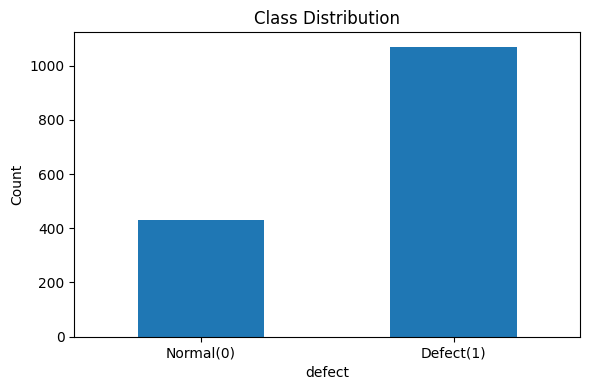

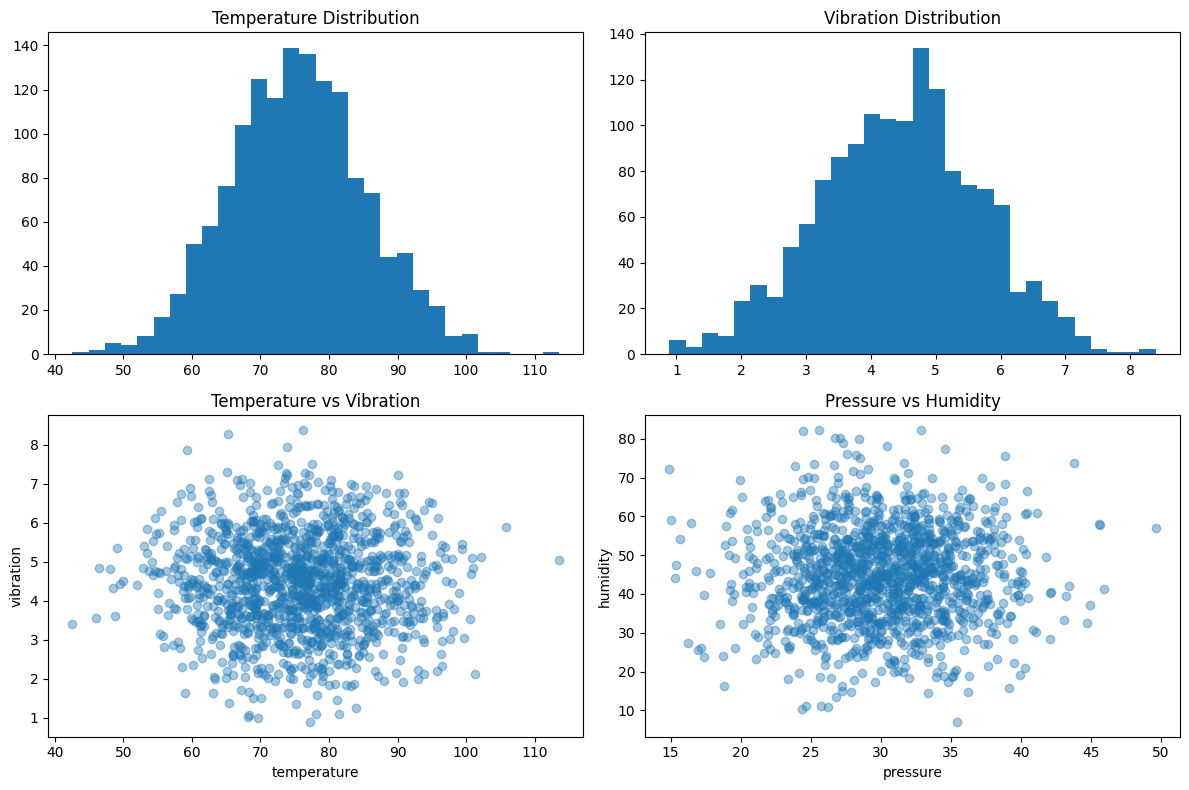

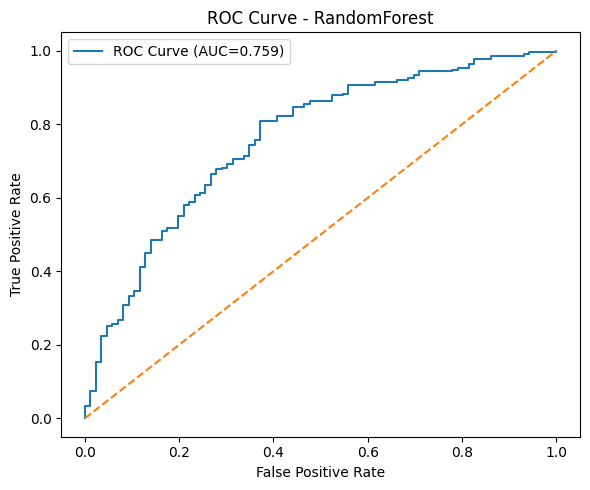

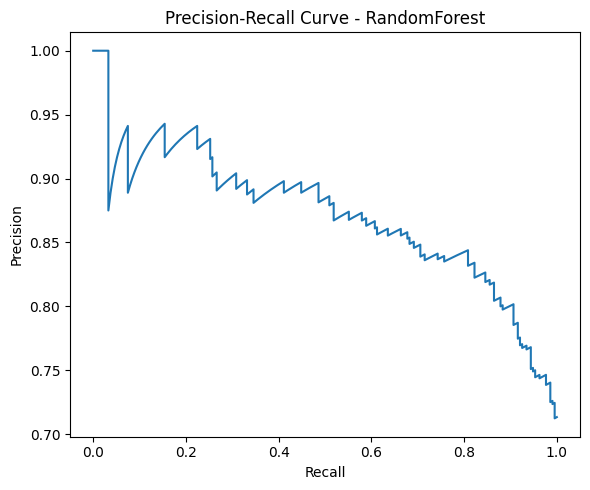

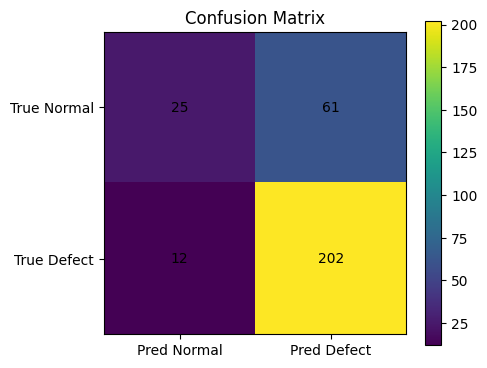


상위 중요 feature
                feature  importance_mean
4                 speed         0.026292
0           temperature         0.008880
3              humidity         0.006978
9        machine_type_B         0.005123
6          energy_proxy         0.004766
8        machine_type_A         0.004456
13   material_grade_low         0.003844
5   temp_pressure_ratio         0.003751
1              pressure         0.002355
10            shift_day         0.001096


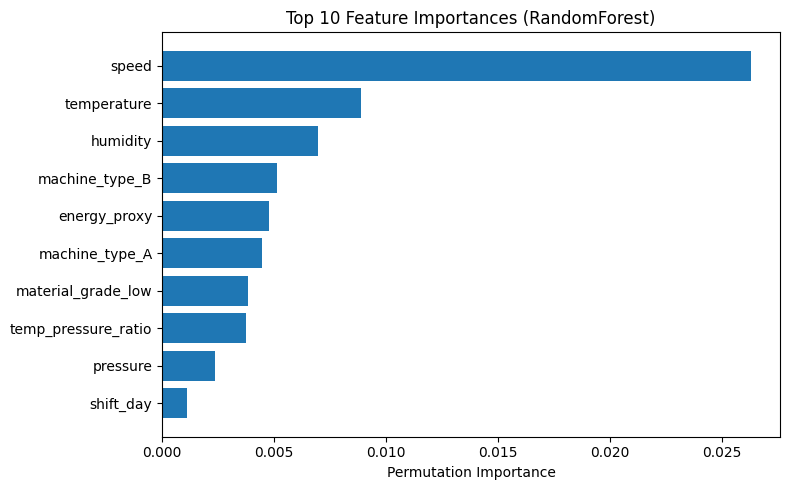


신규 데이터 예측 결과
   temperature  pressure  vibration machine_type  shift material_grade  \
0           82        31        4.8            A    day         medium   
1           95        40        7.2            C  night            low   
2           68        25        3.5            B    day           high   
3           88        36        6.5            C  night         medium   
4           77        29        4.2            A    day         medium   

   predicted_class predicted_label  defect_probability  
0                1          Defect            0.843317  
1                1          Defect            0.928492  
2                0          Normal            0.414054  
3                1          Defect            0.943167  
4                1          Defect            0.747890  


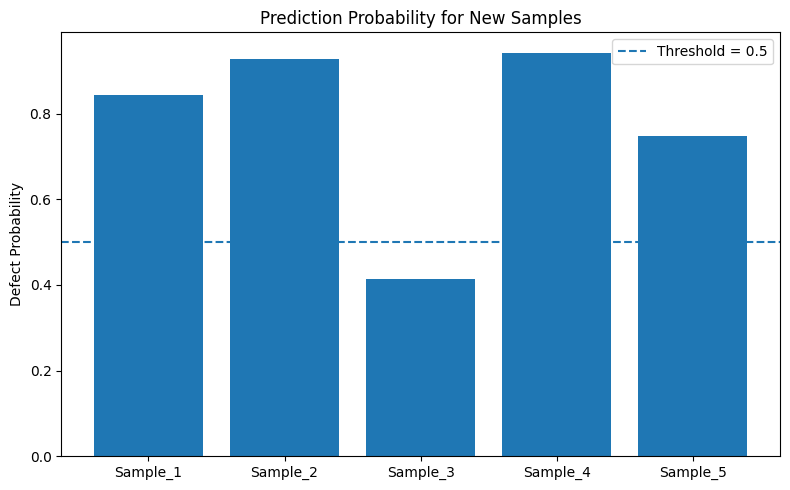


[최종 해석]
- 최종 선택 모델: RandomForest
- 테스트 F1-score: 0.8470
- 테스트 ROC-AUC : 0.7590
- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있습니다.
- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있습니다.


In [3]:
# ============================================================
# 3. Feature Engineering
# ============================================================

# 도메인 기반 feature 생성
df['temp_pressure_ratio'] = df['temperature'] / (df['pressure'] + 1e-6)
df['vibration_torque_interaction'] = df['vibration'] * df['torque']
df['energy_proxy'] = df['torque'] * df['speed']
df['temp_humidity_gap'] = df['temperature'] - df['humidity']
df['stress_index'] = (df['pressure'] * df['vibration']) / (df['operator_experience'] + 1)

# ============================================================
# 4. 데이터 확인
# ============================================================

print("=" * 80)
print("데이터 상위 5행")
print(df.head())
print("=" * 80)

print("\n데이터 정보")
print(df.info())

print("\n클래스 분포")
print(df['defect'].value_counts(normalize=True))

# ============================================================
# 5. 입력/타깃 분리
# ============================================================

X = df.drop(columns=['defect'])
y = df['defect']

numeric_features = [
    'temperature', 'pressure', 'vibration', 'humidity', 'torque',
    'speed', 'operator_experience', 'temp_pressure_ratio',
    'vibration_torque_interaction', 'energy_proxy',
    'temp_humidity_gap', 'stress_index'
]

categorical_features = ['machine_type', 'shift', 'material_grade']

# ============================================================
# 6. 학습/테스트 분리
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================================
# 7. 전처리 파이프라인
# ============================================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ============================================================
# 8. 모델 파이프라인 정의
# ============================================================

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'RandomForest': RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_split=10,
        random_state=42
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

pipelines = {}

for model_name, model in models.items():
    pipelines[model_name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_select', SelectKBest(score_func=mutual_info_classif, k=15)),
        ('classifier', model)
    ])

# ============================================================
# 9. 교차검증 성능 비교
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for model_name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results.append({
        'model': model_name,
        'cv_f1_mean': scores.mean(),
        'cv_f1_std': scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values(by='cv_f1_mean', ascending=False)

print("\n" + "=" * 80)
print("교차검증 결과(F1 기준)")
print(cv_df)
print("=" * 80)

best_model_name = cv_df.iloc[0]['model']
best_pipeline = pipelines[best_model_name]

print(f"\n선정된 최종 모델: {best_model_name}")

# ============================================================
# 10. 최종 모델 학습
# ============================================================

best_pipeline.fit(X_train, y_train)

# ============================================================
# 11. 테스트 데이터 예측
# ============================================================

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# ============================================================
# 12. 모델 평가
# ============================================================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n테스트 성능")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

# ============================================================
# 13. 시각화 1 - 클래스 분포
# ============================================================

plt.figure(figsize=(6, 4))
df['defect'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1], ['Normal(0)', 'Defect(1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ============================================================
# 14. 시각화 2 - 주요 변수 분포
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['temperature'].dropna(), bins=30)
axes[0, 0].set_title('Temperature Distribution')

axes[0, 1].hist(df['vibration'].dropna(), bins=30)
axes[0, 1].set_title('Vibration Distribution')

axes[1, 0].scatter(df['temperature'], df['vibration'], alpha=0.4)
axes[1, 0].set_title('Temperature vs Vibration')
axes[1, 0].set_xlabel('temperature')
axes[1, 0].set_ylabel('vibration')

axes[1, 1].scatter(df['pressure'], df['humidity'], alpha=0.4)
axes[1, 1].set_title('Pressure vs Humidity')
axes[1, 1].set_xlabel('pressure')
axes[1, 1].set_ylabel('humidity')

plt.tight_layout()
plt.show()

# ============================================================
# 15. 시각화 3 - ROC Curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 16. 시각화 4 - Precision-Recall Curve
# ============================================================

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.tight_layout()
plt.show()

# ============================================================
# 17. 시각화 5 - Confusion Matrix
# ============================================================

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Pred Normal', 'Pred Defect'])
plt.yticks([0, 1], ['True Normal', 'True Defect'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

# ============================================================
# 18. 모델 해석 - Permutation Importance
# ============================================================

# 전처리 완료 후 피처 이름 얻기
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
feature_selector = best_pipeline.named_steps['feature_select']
classifier = best_pipeline.named_steps['classifier']

X_test_transformed = preprocessor_fitted.transform(X_test)

# onehot 포함 전체 feature name
cat_ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_ohe.get_feature_names_out(categorical_features)
all_feature_names = np.array(numeric_features + list(cat_feature_names))

selected_mask = feature_selector.get_support()
selected_feature_names = all_feature_names[selected_mask]

X_test_selected = feature_selector.transform(X_test_transformed)

perm_result = permutation_importance(
    classifier, X_test_selected, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

importance_df = pd.DataFrame({
    'feature': selected_feature_names,
    'importance_mean': perm_result.importances_mean
}).sort_values(by='importance_mean', ascending=False)

print("\n상위 중요 feature")
print(importance_df.head(10))

plt.figure(figsize=(8, 5))
top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['importance_mean'])
plt.title(f'Top {top_n} Feature Importances ({best_model_name})')
plt.xlabel('Permutation Importance')
plt.tight_layout()
plt.show()

# ============================================================
# 19. 신규 데이터 예측
# ============================================================

new_samples = pd.DataFrame({
    'temperature': [82, 95, 68, 88, 77],
    'pressure': [31, 40, 25, 36, 29],
    'vibration': [4.8, 7.2, 3.5, 6.5, 4.2],
    'humidity': [48, 62, 38, 50, 44],
    'torque': [230, 280, 190, 260, 215],
    'speed': [1480, 1320, 1580, 1400, 1510],
    'operator_experience': [5, 2, 8, 3, 6],
    'machine_type': ['A', 'C', 'B', 'C', 'A'],
    'shift': ['day', 'night', 'day', 'night', 'day'],
    'material_grade': ['medium', 'low', 'high', 'medium', 'medium']
})

# 동일한 feature engineering 적용
new_samples['temp_pressure_ratio'] = new_samples['temperature'] / (new_samples['pressure'] + 1e-6)
new_samples['vibration_torque_interaction'] = new_samples['vibration'] * new_samples['torque']
new_samples['energy_proxy'] = new_samples['torque'] * new_samples['speed']
new_samples['temp_humidity_gap'] = new_samples['temperature'] - new_samples['humidity']
new_samples['stress_index'] = (new_samples['pressure'] * new_samples['vibration']) / (new_samples['operator_experience'] + 1)

new_pred = best_pipeline.predict(new_samples)
new_proba = best_pipeline.predict_proba(new_samples)[:, 1]

result_df = new_samples.copy()
result_df['predicted_class'] = new_pred
result_df['defect_probability'] = new_proba
result_df['predicted_label'] = result_df['predicted_class'].map({0: 'Normal', 1: 'Defect'})

print("\n신규 데이터 예측 결과")
print(result_df[['temperature', 'pressure', 'vibration', 'machine_type',
                 'shift', 'material_grade', 'predicted_class',
                 'predicted_label', 'defect_probability']])

# ============================================================
# 20. 시각화 6 - 신규 데이터 예측 확률
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(range(len(result_df)), result_df['defect_probability'])
plt.axhline(0.5, linestyle='--', label='Threshold = 0.5')
plt.xticks(range(len(result_df)), [f'Sample_{i+1}' for i in range(len(result_df))])
plt.ylabel('Defect Probability')
plt.title('Prediction Probability for New Samples')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 21. 간단 해석 출력
# ============================================================

print("\n[최종 해석]")
print(f"- 최종 선택 모델: {best_model_name}")
print(f"- 테스트 F1-score: {f1:.4f}")
print(f"- 테스트 ROC-AUC : {roc_auc:.4f}")
print("- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있습니다.")
print("- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있습니다.")